# Análise do CICDDoS2019 01/12

## Criação do Dataset Balanceado

In [ ]:
from src.Data.Handler import DatasetHandler

handler = DatasetHandler(logging=True)

handler.create_balanced_dataset(
    src_dir="C:/GitHub/anomaly-detection-data-stream/datasets/CICDDoS2019/01-12", 
    dest_dir="data", 
    output_filename="BALANCED.CSV", 
    n_samples_per_class=10000,
    chunk_size=100000,
    target_files=None,
    ignored_classes=['WebDDoS'],
    allow_insufficient=True
)

## Análise de Similaridade

In [3]:
import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Data.Handler import DatasetHandler

# Instancia as duas ferramentas
processor = DataStreamProcessor(logging=True)
handler = DatasetHandler(logging=True)

# Carrega o CSV 
df_bruto = pd.read_csv('data/BALANCED.CSV')

# Pré-Processamento 
X_df, y_array, target_names = processor.create_stream(
    df=df_bruto,
    target_label_col='Label',
    binary_label=False,               # Falso pois queremos ver CADA ataque separado
    normalize_method='StandardScaler',  # Normaliza entre 0 e 1
    imputation_method='median',            # Substitui NaNs por 0
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol', 'Inbound'],
    return_stream=False               # Retorna (DataFrame de Features, Array de Labels, Nomes)
)

# Executa a Seleção OvR (One-vs-Rest)
dict_features, vetor_features_finais = handler.extract_ovr_feature_importance(
    X=X_df, 
    y=y_array, 
    target_names=target_names,
    top_per_class=10
)

Limpeza: Removendo espaços, identificadores e colunas vazias...
Pré-processamento: Convertendo infinitos...
Aviso: Método de preenchimento 'median' desconhecido. Usando ZERO por padrão.
Normalização: StandardScaler
Target: Mantendo multiclasse (Forçando BENIGN=0)...
Seleção de Features: Nenhuma técnica dinâmica selecionada. Mantendo colunas atuais.
Finalização: Retornando DataFrame pandas processado.


 INICIANDO EXTRAÇÃO DE FEATURES OVR (ONE-VS-REST)
 [*] Analisando Assinatura Local: BENIGN vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_DNS vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_LDAP vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_MSSQL vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_NetBIOS vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_NTP vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_SNMP vs Resto do Tráfego...
 [*] Analisando Assinatura Local: DrDoS_SSDP vs Resto do Tráfego...
 [

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


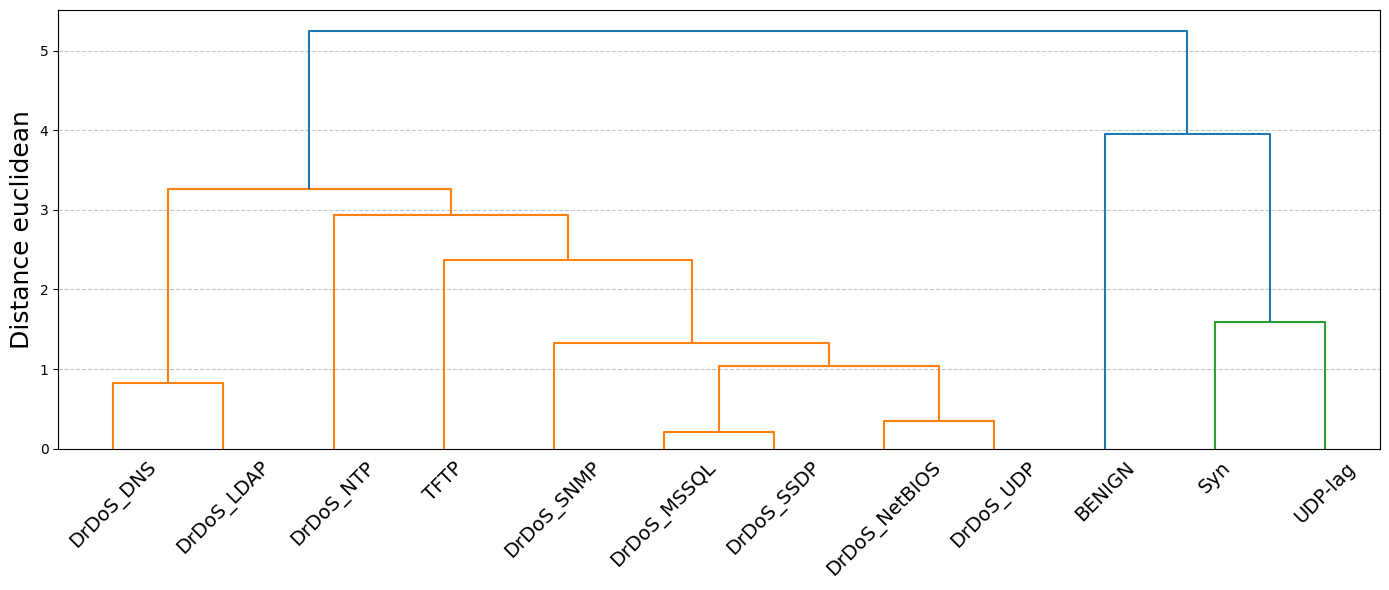

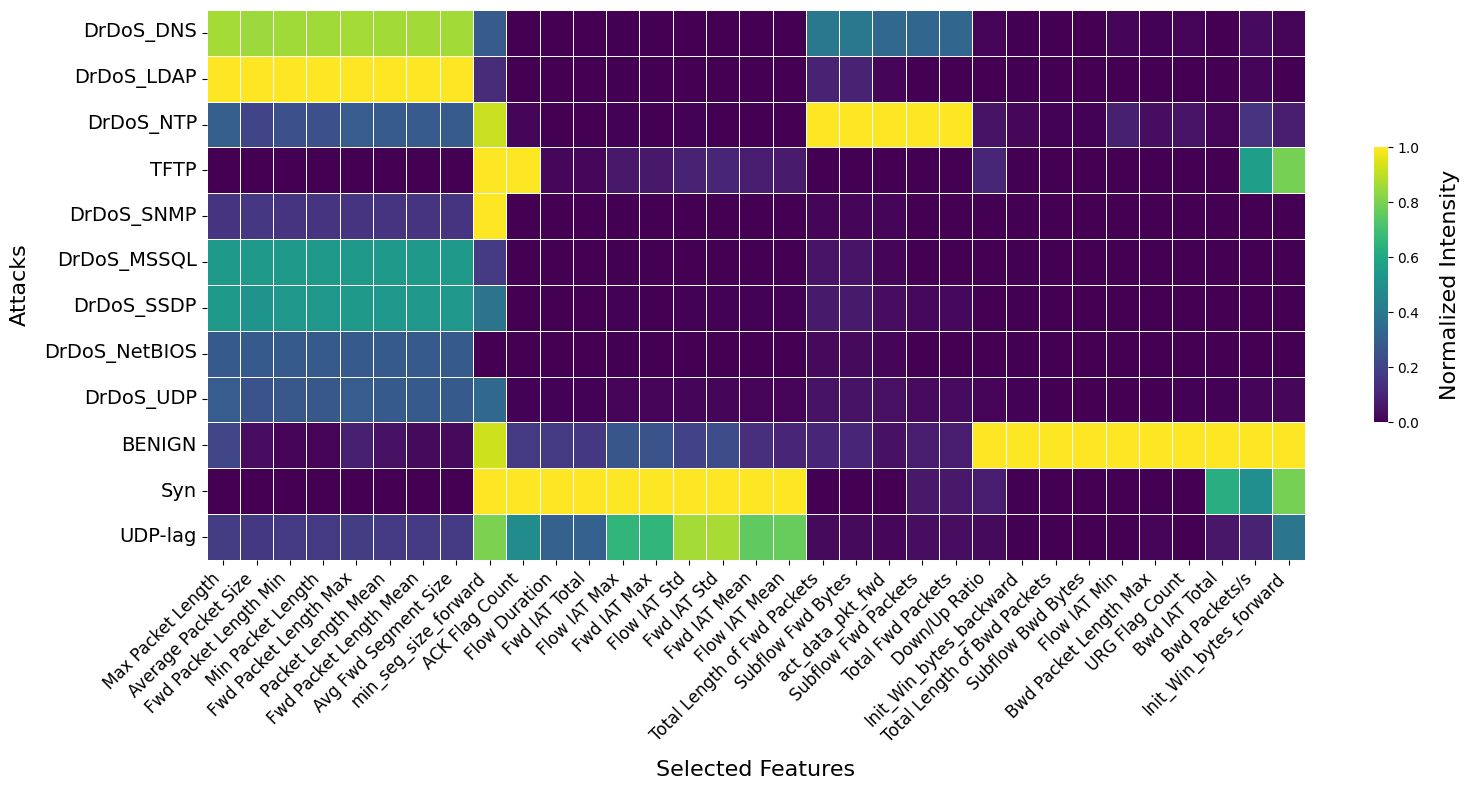

features = [
    'Max Packet Length',
    'Average Packet Size',
    'Fwd Packet Length Min',
    'Min Packet Length',
    'Fwd Packet Length Max',
    'Packet Length Mean',
    'Fwd Packet Length Mean',
    'Avg Fwd Segment Size',
    'min_seg_size_forward',
    'ACK Flag Count',
    'Flow Duration',
    'Fwd IAT Total',
    'Flow IAT Max',
    'Fwd IAT Max',
    'Flow IAT Std',
    'Fwd IAT Std',
    'Fwd IAT Mean',
    'Flow IAT Mean',
    'Total Length of Fwd Packets',
    'Subflow Fwd Bytes',
    'act_data_pkt_fwd',
    'Subflow Fwd Packets',
    'Total Fwd Packets',
    'Down/Up Ratio',
    'Init_Win_bytes_backward',
    'Total Length of Bwd Packets',
    'Subflow Bwd Bytes',
    'Flow IAT Min',
    'Bwd Packet Length Max',
    'URG Flag Count',
    'Bwd IAT Total',
    'Bwd Packets/s',
    'Init_Win_bytes_forward',
]


In [24]:
%load_ext autoreload
%autoreload 2

# Plota os Dendrogramas e Mapas de Calor
handler.plot_similarity_and_feature_groups(
    X=X_df, 
    y=y_array, 
    target_names=target_names,
    selected_features=vetor_features_finais, 
    metric='euclidean',
    linkage_method='ward'
)

# Criação de cenários

## Média de Amostras Normais 15k

In [ ]:
AMOSTRAS = [25, 200, 1000]
BASELINE = "data/BENIGN.csv"
INPUT_FOLDER = "C:\\GitHub\\anomaly-detection-data-stream\\datasets\\CICDDoS2019\\01-12"
OUTPUT_FOLDER = "data/15k"

### Cenário de Consistência

In [ ]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Consistência/Consistência_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])

### Cenário Generalização

In [ ]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras),
        ("DrDoS_LDAP.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Generalização/Generalização_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])

### Cenário Adaptação

In [ ]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras),
        ("Syn.csv", qtd_amostras),
        ("DrDoS_DNS.csv", qtd_amostras)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Adaptação/Adaptação_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])

### Cenário de Recorrência

In [ ]:
from src.Data.ScenarioGenerator import ScenarioGenerator

for qtd_amostras in AMOSTRAS:
    
    meu_cenario = [
        ("DrDoS_DNS.csv", qtd_amostras//2),
        ("Syn.csv", qtd_amostras//2),
        ("DrDoS_LDAP.csv", qtd_amostras//2),
        ("DrDoS_DNS.csv", qtd_amostras//2),
        ("Syn.csv", qtd_amostras//2),
        ("DrDoS_LDAP.csv", qtd_amostras//2)
    ]

    caminho_saida = f"{OUTPUT_FOLDER}/Recorrência/Recorrência_{qtd_amostras}.csv"

    gerador = ScenarioGenerator(
        input_folder=INPUT_FOLDER,
        output_path=caminho_saida,
        baseline_file=BASELINE,
        logging=True,
        n_benign_samples=15000, 
        sort_by_timestamp=False,
        remove_duplicates=False
    )

    gerador.generate(meu_cenario)
    gerador.plot_scenario(window_size=250, features_plot=['Total Fwd Packets', 'Total Backward Packets'])